In [33]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
import glob
from sklearn.preprocessing import LabelEncoder

In [34]:
#Load PBP, filter to valid plays, and check for coverage type data
#cover 6, cover 9, and combo merged into cover 4 -> cover 6 is half cover 2 and cover 4, hard to identify clearly. Cover9 is deep drop, similar to cover 4
pbp = nfl.import_pbp_data([2023])

mask = (
    (pbp['play_type'] == 'pass') &
    (pbp['defense_coverage_type'].notna()) &
    (pbp['defense_coverage_type'] != '') &
    (pbp['defense_coverage_type'] != 'BLOWN')
)
labels = pbp.loc[mask, ['old_game_id_x', 'play_id', 'defense_coverage_type']].copy()
labels.rename(columns={'old_game_id_x': 'game_id', 'play_id': 'play_id_pbp'}, inplace=True)
labels['game_id'] = labels['game_id'].astype(int)
labels['play_id_pbp'] = labels['play_id_pbp'].astype(int)

#Merge COMBO, COVER_6, COVER_9 into COVER_4
labels['defense_coverage_type'] = labels['defense_coverage_type'].replace({
    'COMBO': 'COVER_4',
    'COVER_6': 'COVER_4',
    'COVER_9': 'COVER_4',
})

print(f'Labeled pass plays: {len(labels)}')
print(labels['defense_coverage_type'].value_counts())

2023 done.
Downcasting floats.
Labeled pass plays: 20616
defense_coverage_type
COVER_1    6640
COVER_4    5056
COVER_3    3734
COVER_2    3237
2_MAN      1243
COVER_0     706
Name: count, dtype: int64


In [35]:
#Load all tracking CSVs
csv_files = sorted(glob.glob('csv/input_2023_w*.csv'))
tracking = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)
print(f'Tracking rows: {len(tracking):,}')
print(f'Unique plays: {tracking.groupby(["game_id", "play_id"]).ngroups:,}')

Tracking rows: 4,880,579
Unique plays: 14,108


In [36]:
#Join tracking with coverage labels
tracking_labeled = tracking.merge(
    labels,
    left_on=['game_id', 'play_id'],
    right_on=['game_id', 'play_id_pbp'],
    how='inner'
)
print(f'Matched tracking rows: {len(tracking_labeled):,}')
print(f'Matched plays: {tracking_labeled.groupby(["game_id", "play_id"]).ngroups:,}')

Matched tracking rows: 4,868,357
Matched plays: 14,075


In [37]:
#Extract snap + post-snap frames, normalize direction
#10 fps: frames 1,3,5,7,9,11,13,15,17,19,21 = every 0.2s from snap to 2.0s
FRAME_SNAP = 1
POST_FRAMES = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21]

# Pull all needed frames at once
needed_frames = [FRAME_SNAP] + POST_FRAMES
frames_df = tracking_labeled[tracking_labeled['frame_id'].isin(needed_frames)].copy()

#Normalize play direction: flip so all plays go right
left_mask = frames_df['play_direction'] == 'left'
frames_df.loc[left_mask, 'x'] = 120.0 - frames_df.loc[left_mask, 'x']
frames_df.loc[left_mask, 'y'] = 53.3 - frames_df.loc[left_mask, 'y']

#Pivot: merge all frames per player into one row
snap = frames_df[frames_df['frame_id'] == FRAME_SNAP].copy()
key = ['game_id', 'play_id', 'nfl_id']

merged = snap.copy()
for f in POST_FRAMES:
    frame_data = frames_df[frames_df['frame_id'] == f][key + ['x', 'y']]
    merged = merged.merge(frame_data, on=key, how='inner', suffixes=('', f'_f{f}'))

#Compute displacements from snap for each post-snap frame
for f in POST_FRAMES:
    merged[f'dx_f{f}'] = merged[f'x_f{f}'] - merged['x']
    merged[f'dy_f{f}'] = merged[f'y_f{f}'] - merged['y']

#Drop plays that don't have all frames (play ended early)
print(f'Players with all {len(needed_frames)} frames: {len(merged):,}')
print(f'Plays with all frames: {merged.groupby(["game_id", "play_id"]).ngroups:,}')

Players with all 11 frames: 141,345
Plays with all frames: 11,503


In [38]:
#Build feature vectors with per-player + formation-level features
#
# Per defender (8 max): [x, y, depth, nearest_recv_dist, dist_center, 20 displacements] = 25
# Per offensive (6 max): [x, y, 20 displacements] = 22
# Formation-level (1 per play):
#   - n_deep: defenders > 10 yds from LOS
#   - n_box: defenders within 5 yds of LOS
#   - safety_count_high: safeties deeper than 12 yds (1-high vs 2-high read)
#   - avg_def_depth: average defender depth from LOS
#   - def_spread: std of defender y-positions (wide vs compact)
#   - avg_corner_press: average distance of two widest defenders to nearest WR
#   - max_def_depth: deepest defender depth
# Total: 8*25 + 6*22 + 7 = 339 features

N_DEF, N_OFF = 8, 6
DISP_COLS = []
for f in POST_FRAMES:
    DISP_COLS += [f'dx_f{f}', f'dy_f{f}']

FIELD_CENTER_Y = 26.65

def build_feature_vector(play_df):
    defense = play_df[play_df['player_side'] == 'Defense'].sort_values('y')
    offense = play_df[play_df['player_side'] == 'Offense'].sort_values('y')

    if len(defense) < 4 or len(offense) < 3:
        return None

    los_x = offense['x'].mean()
    off_xy = offense[['x', 'y']].values
    def_xy = defense[['x', 'y']].values

    # --- Per-defender features ---
    def_depths = def_xy[:, 0] - los_x  # positive = deeper behind LOS
    def_feats = []
    nearest_dists = []
    for idx, (_, row) in enumerate(defense.iterrows()):
        dists = np.sqrt((off_xy[:, 0] - row['x'])**2 + (off_xy[:, 1] - row['y'])**2)
        nearest_dist = dists.min()
        nearest_dists.append(nearest_dist)
        depth = def_depths[idx]
        dist_center = abs(row['y'] - FIELD_CENTER_Y)
        feat = [row['x'], row['y'], depth, nearest_dist, dist_center]
        feat += [row[c] for c in DISP_COLS]
        def_feats.append(feat)

    # --- Per-offense features ---
    off_feats = []
    for _, row in offense.iterrows():
        feat = [row['x'], row['y']]
        feat += [row[c] for c in DISP_COLS]
        off_feats.append(feat)

    # --- Formation-level features ---
    n_deep = int((def_depths > 10).sum())
    n_box = int((def_depths < 5).sum())
    safety_high = int((def_depths > 12).sum())  # 1-high vs 2-high
    avg_depth = float(def_depths.mean())
    def_spread = float(def_xy[:, 1].std())
    max_depth = float(def_depths.max())
    # Corner press: two widest defenders' distance to nearest receiver
    sorted_by_width = np.argsort(np.abs(def_xy[:, 1] - FIELD_CENTER_Y))[::-1]
    corner_dists = [nearest_dists[i] for i in sorted_by_width[:2]]
    avg_corner_press = float(np.mean(corner_dists))

    formation = [n_deep, n_box, safety_high, avg_depth, def_spread, avg_corner_press, max_depth]

    # --- Pad and combine ---
    def_fpp = 5 + len(DISP_COLS)
    off_fpp = 2 + len(DISP_COLS)

    def pad(feats, n, fpp):
        arr = np.array(feats[:n])
        if len(arr) < n:
            arr = np.vstack([arr, np.zeros((n - len(arr), fpp))])
        return arr.flatten()

    return np.concatenate([
        pad(def_feats, N_DEF, def_fpp),
        pad(off_feats, N_OFF, off_fpp),
        np.array(formation, dtype=np.float32)
    ])

rows, coverage_labels = [], []
for (gid, pid), play_df in merged.groupby(['game_id', 'play_id']):
    vec = build_feature_vector(play_df)
    if vec is not None:
        rows.append(vec)
        coverage_labels.append(play_df['defense_coverage_type'].iloc[0])

X = np.array(rows, dtype=np.float32)
y = np.array(coverage_labels)

print(f'Feature matrix: {X.shape}')
print(f'\nLabel distribution:')
unique, counts = np.unique(y, return_counts=True)
for label, count in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {label}: {count} ({count/len(y)*100:.1f}%)')

Feature matrix: (11492, 339)

Label distribution:
  COVER_1: 3593 (31.3%)
  COVER_4: 2848 (24.8%)
  COVER_3: 2221 (19.3%)
  COVER_2: 1893 (16.5%)
  2_MAN: 689 (6.0%)
  COVER_0: 248 (2.2%)


In [39]:
#Encode labels and save
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Label mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i}: {cls}')

np.savez('processed_2023.npz', X=X, y=y_encoded, classes=le.classes_)
print(f'\nSaved processed_2023.npz — X: {X.shape}, y: {y_encoded.shape}')

Label mapping:
  0: 2_MAN
  1: COVER_0
  2: COVER_1
  3: COVER_2
  4: COVER_3
  5: COVER_4

Saved processed_2023.npz — X: (11492, 339), y: (11492,)


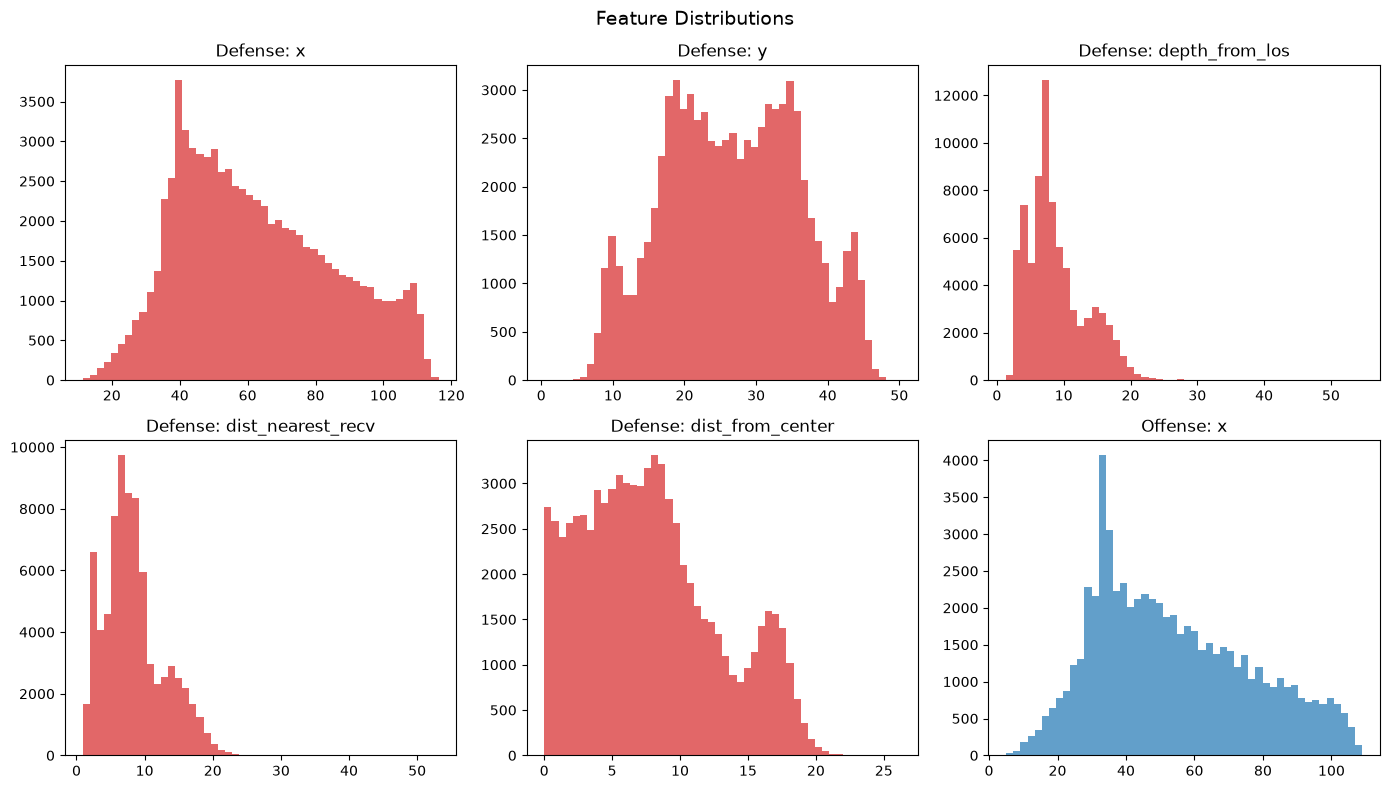

In [40]:
# --- 8. Feature distributions (snap features only) ---
import matplotlib.pyplot as plt

# Defense snap features: x, y, depth, nearest_dist, dist_center (first 5 of each defender's 25)
def_fpp = 25
off_fpp = 22
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
def_snap_names = ['x', 'y', 'depth_from_los', 'dist_nearest_recv', 'dist_from_center']

for i, (ax, name) in enumerate(zip(axes.flatten()[:5], def_snap_names)):
    cols = [i + p * def_fpp for p in range(N_DEF)]
    vals = X[:, cols].flatten()
    vals = vals[vals != 0]
    ax.hist(vals, bins=50, alpha=0.7, color='tab:red')
    ax.set_title(f'Defense: {name}')

# One offense feature: snap x position
off_start = N_DEF * def_fpp
cols = [off_start + p * off_fpp for p in range(N_OFF)]
vals = X[:, cols].flatten()
vals = vals[vals != 0]
axes[1, 2].hist(vals, bins=50, alpha=0.7, color='tab:blue')
axes[1, 2].set_title('Offense: x')

fig.suptitle('Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()